In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam


In [ ]:
metadata = pd.read_csv('/content/HAM10000_metadata.csv')
metadata.head()


,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


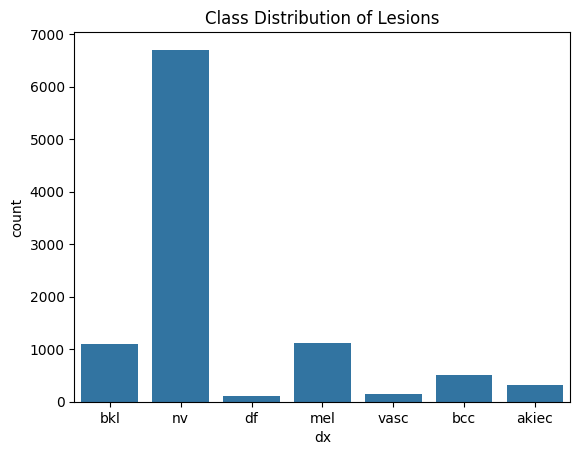

In [ ]:
sns.countplot(x='dx', data=metadata)
plt.title('Class Distribution of Lesions')
plt.show()


In [ ]:
import cv2
from tqdm import tqdm

base_dir = '/content/HAM10000_images_part_1'  # change if needed
image_size = 128

X = []
y = []

for i, row in tqdm(metadata.iterrows(), total=len(metadata)):
    img_path = os.path.join(base_dir, row['image_id'] + '.jpg')
    if not os.path.exists(img_path):
        img_path = '/content/HAM10000_images_part_2/' + row['image_id'] + '.jpg'
    img = cv2.imread(img_path)
    img = cv2.resize(img, (image_size, image_size))
    X.append(img)
    y.append(row['dx'])

X = np.array(X)
y = np.array(y)


In [ ]:
from google.colab import files
files.upload()


Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"faisalmujtaba","key":"81e233b850a254dec0e4ae9aa2a38d3d"}'}

In [ ]:
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json


In [ ]:
!kaggle datasets download -d kmader/skin-cancer-mnist-ham10000


Dataset URL: https://www.kaggle.com/datasets/kmader/skin-cancer-mnist-ham10000
License(s): CC-BY-NC-SA-4.0
100% 5.20G/5.20G [02:12<00:00, 29.4MB/s]
100% 5.20G/5.20G [02:12<00:00, 42.2MB/s]


In [ ]:
!unzip skin-cancer-mnist-ham10000.zip -d /content/HAM10000


Streaming output truncated to the last 5000 lines.
  inflating: /content/HAM10000/ham10000_images_part_2/ISIC_0029325.jpg  
  inflating: /content/HAM10000/ham10000_images_part_2/ISIC_0029326.jpg  
  inflating: /content/HAM10000/ham10000_images_part_2/ISIC_0029327.jpg  
  inflating: /content/HAM10000/ham10000_images_part_2/ISIC_0029328.jpg  
  inflating: /content/HAM10000/ham10000_images_part_2/ISIC_0029329.jpg  
  inflating: /content/HAM10000/ham10000_images_part_2/ISIC_0029330.jpg  
  inflating: /content/HAM10000/ham10000_images_part_2/ISIC_0029331.jpg  
  inflating: /content/HAM10000/ham10000_images_part_2/ISIC_0029332.jpg  
  inflating: /content/HAM10000/ham10000_images_part_2/ISIC_0029333.jpg  
  inflating: /content/HAM10000/ham10000_images_part_2/ISIC_0029334.jpg  
  inflating: /content/HAM10000/ham10000_images_part_2/ISIC_0029335.jpg  
  inflating: /content/HAM10000/ham10000_images_part_2/ISIC_0029336.jpg  
  inflating: /content/HAM10000/ham10000_images_part_2/ISIC_0029337.jpg  


In [ ]:
import os
os.listdir('/content/HAM10000')


['ham10000_images_part_1',
 'hmnist_28_28_RGB.csv',
 'ham10000_images_part_2',
 'hmnist_8_8_L.csv',
 'HAM10000_metadata.csv',
 'hmnist_8_8_RGB.csv',
 'HAM10000_images_part_2',
 'HAM10000_images_part_1',
 'hmnist_28_28_L.csv']

In [ ]:
metadata = pd.read_csv('/content/HAM10000/HAM10000_metadata.csv')


In [ ]:
path1 = '/content/HAM10000/HAM10000_images_part_1'
path2 = '/content/HAM10000/HAM10000_images_part_2'


In [ ]:
# Import Libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import cv2
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import confusion_matrix, classification_report


In [ ]:
# Load and Explore Data
metadata = pd.read_csv('/content/HAM10000/HAM10000_metadata.csv')
metadata.head()


,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


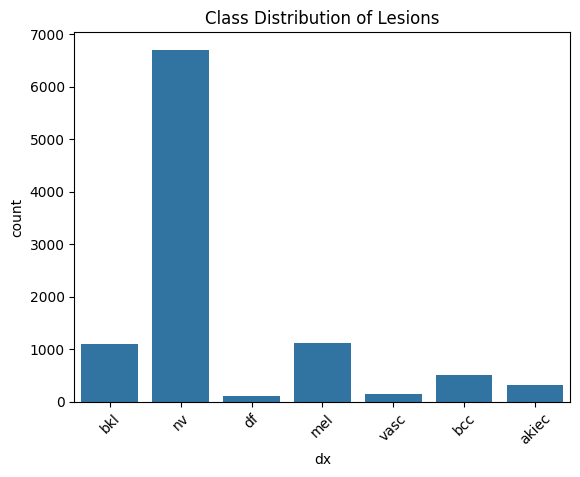

In [ ]:
# Visualize class distribution
sns.countplot(x='dx', data=metadata)
plt.title('Class Distribution of Lesions')
plt.xticks(rotation=45)
plt.show()


In [ ]:
#Image Loading & Preprocessing
image_size = 128
X, y = [], []

for i, row in tqdm(metadata.iterrows(), total=len(metadata)):
    img_id = row['image_id'] + '.jpg'

    # Updated paths for Kaggle version
    path1 = f'/content/HAM10000/HAM10000_images_part_1/{img_id}'
    path2 = f'/content/HAM10000/HAM10000_images_part_2/{img_id}'

    if os.path.exists(path1):
        img_path = path1
    elif os.path.exists(path2):
        img_path = path2
    else:
        continue

    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (image_size, image_size))
    X.append(img)
    y.append(row['dx'])

X = np.array(X)
y = np.array(y)
print("Image data shape:", X.shape)
print("Label data shape:", y.shape)


100%|██████████| 10015/10015 [01:18<00:00, 127.09it/s]


Image data shape: (10015, 128, 128, 3)
Label data shape: (10015,)


In [ ]:
# Encode Labels

le = LabelEncoder()
y_encoded = le.fit_transform(y)
y_categorical = to_categorical(y_encoded)

print("Classes:", le.classes_)


Classes: ['akiec' 'bcc' 'bkl' 'df' 'mel' 'nv' 'vasc']


In [ ]:
# Split into Train/Test

X_train, X_test, y_train, y_test = train_test_split(
    X, y_categorical, test_size=0.2, random_state=42, stratify=y_categorical
)

# Normalize
X_train = X_train / 255.0
X_test = X_test / 255.0


In [ ]:
# Data Augmentation

datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    vertical_flip=True,
    zoom_range=0.2
)
datagen.fit(X_train)


In [ ]:
# CNN Model Architecture

model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(image_size, image_size, 3)),
    BatchNormalization(),
    MaxPooling2D(2,2),
    Dropout(0.25),

    Conv2D(64, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),
    Dropout(0.25),

    Conv2D(128, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),
    Dropout(0.25),

    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(7, activation='softmax')
])

model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 126, 126, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 61, 61, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 28, 28, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,518,727 (24.87 MB)

 Trainable params: 6,518,279 (24.87 MB)

 Non-trainable params: 448 (1.75 KB)

In [ ]:
# Train the Model

history = model.fit(
    datagen.flow(X_train, y_train, batch_size=32),
    epochs=5,
    validation_data=(X_test, y_test)
)


Epoch 1/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 443s 2s/step - accuracy: 0.6578 - loss: 0.9840 - val_accuracy: 0.1113 - val_loss: 8.1802
Epoch 2/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 448s 2s/step - accuracy: 0.6725 - loss: 0.9395 - val_accuracy: 0.5801 - val_loss: 1.7935
Epoch 3/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 431s 2s/step - accuracy: 0.6758 - loss: 0.8751 - val_accuracy: 0.6850 - val_loss: 1.6031
Epoch 4/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 437s 2s/step - accuracy: 0.6838 - loss: 0.8977 - val_accuracy: 0.6960 - val_loss: 0.9886
Epoch 5/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 437s 2s/step - accuracy: 0.6951 - loss: 0.8323 - val_accuracy: 0.6625 - val_loss: 1.0240


In [ ]:
# Evaluate the Model

test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"✅ Test Accuracy: {test_acc:.3f}")


In [ ]:
# Plot training history
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


In [ ]:
# Confusion matrix and classification report
y_pred = np.argmax(model.predict(X_test), axis=1)
y_true = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

print(classification_report(y_true, y_pred, target_names=le.classes_))


In [ ]:
# Save the Model

model.save('/content/skin_cancer_cnn_model.h5')
print("✅ Model saved successfully at /content/skin_cancer_cnn_model.h5")
